In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from google.colab import files
uploaded=files.upload()

Saving indian_liver_patient - indian_liver_patient.csv to indian_liver_patient - indian_liver_patient.csv


In [3]:
df=pd.read_csv('indian_liver_patient - indian_liver_patient.csv')
df.describe()
df.shape
df.info()
df.isnull().sum()
df=df.dropna()
df.shape
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB
Age                           0
Gender                        0
Total_Bilirubin            

<Axes: >

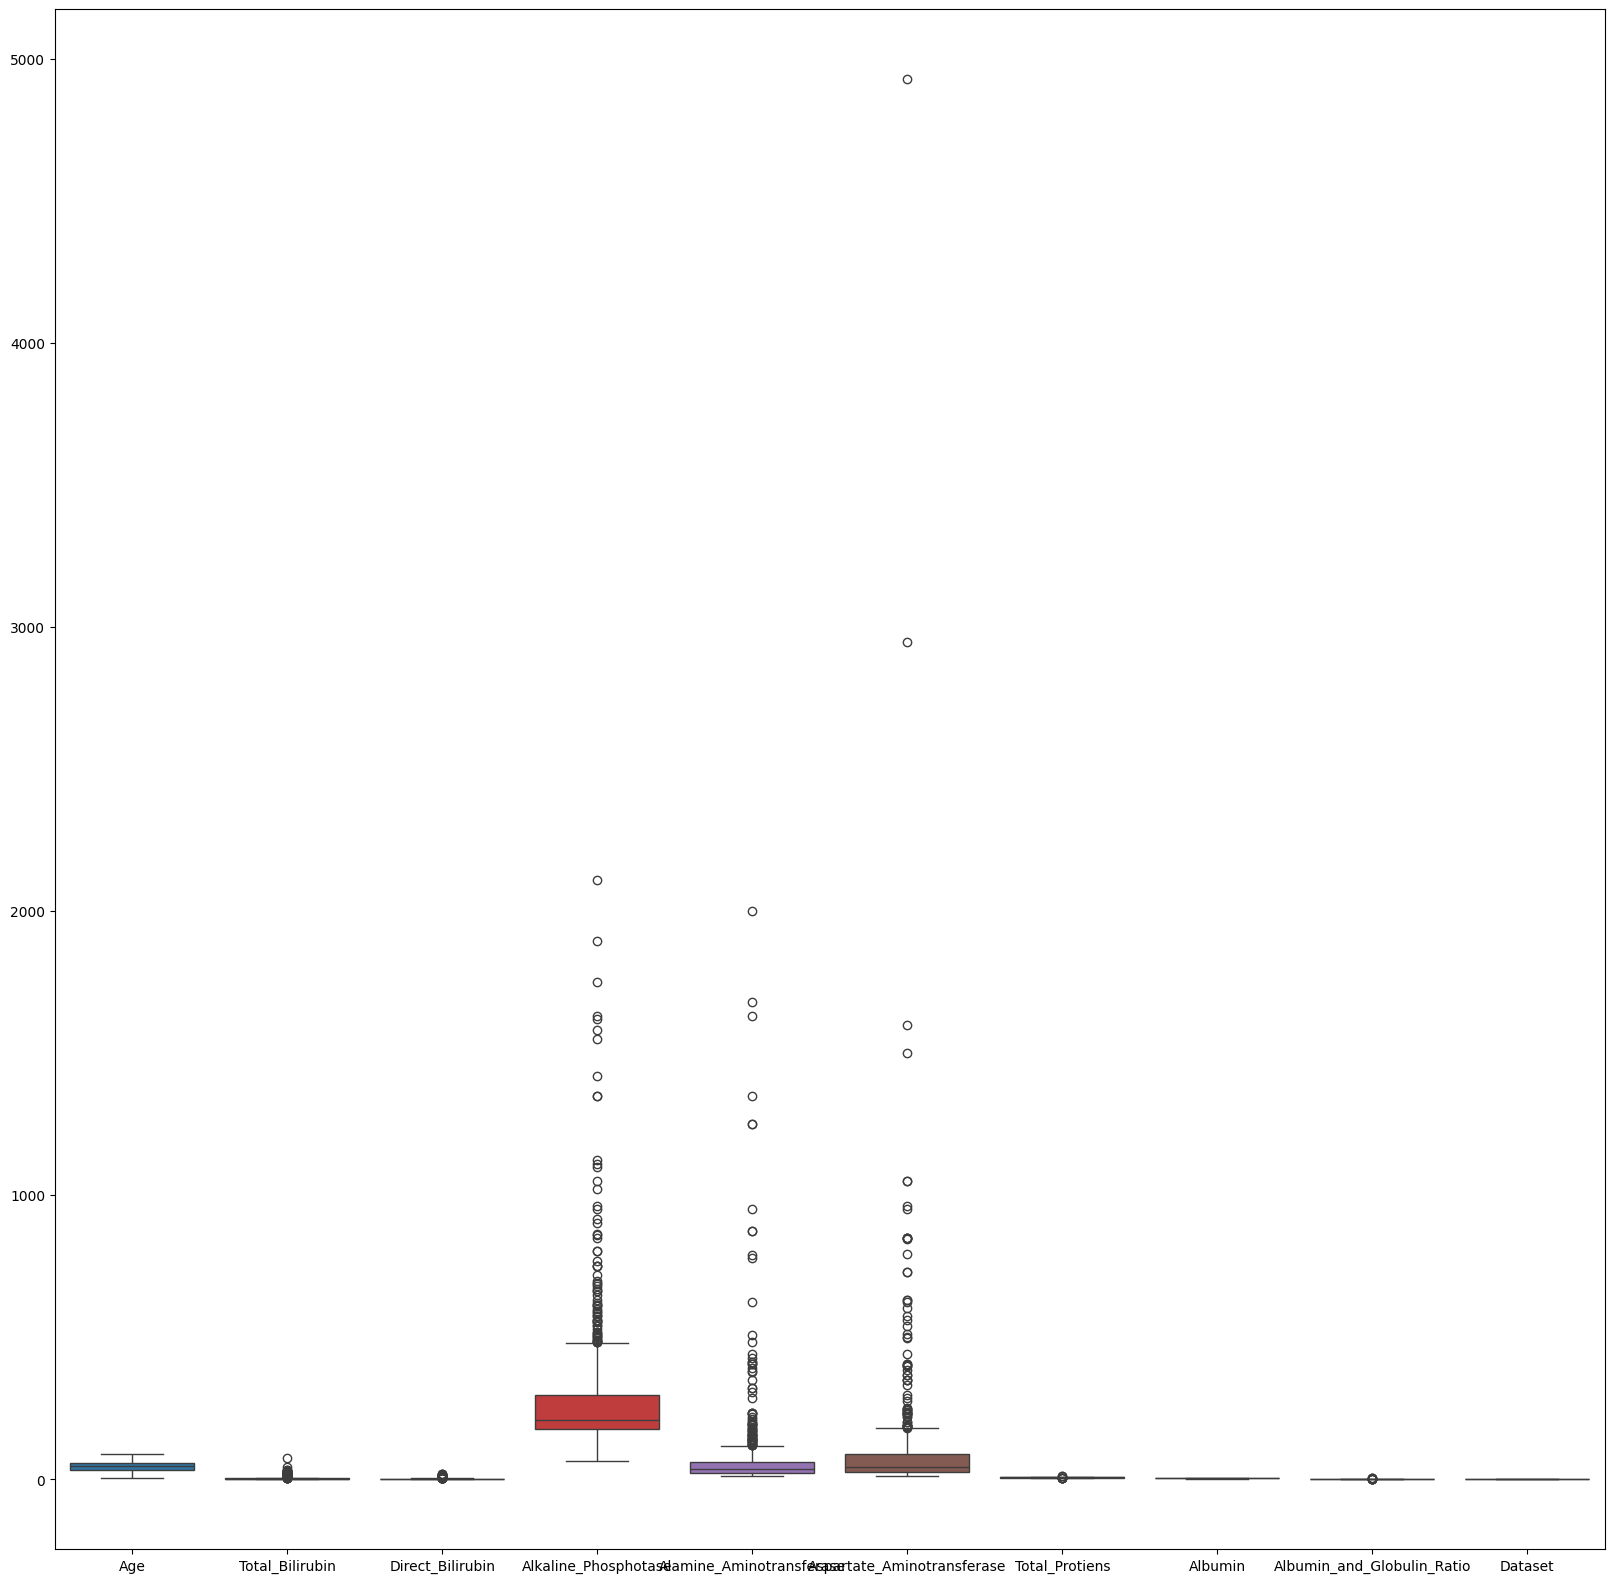

In [4]:
fig, ax = plt.subplots(figsize=(20,20))
sns.boxplot(data=df,ax=ax)

     Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0     65  Female              0.7               0.1                   187   
3     58    Male              1.0               0.4                   182   
4     72    Male              3.9               2.0                   195   
5     46    Male              1.8               0.7                   208   
6     26  Female              0.9               0.2                   154   
..   ...     ...              ...               ...                   ...   
577   32    Male             12.7               8.4                   190   
579   40    Male              0.6               0.1                    98   
580   52    Male              0.8               0.2                   245   
581   31    Male              1.3               0.5                   184   
582   38    Male              1.0               0.3                   216   

     Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  

<Axes: xlabel='Alkaline_Phosphotase'>

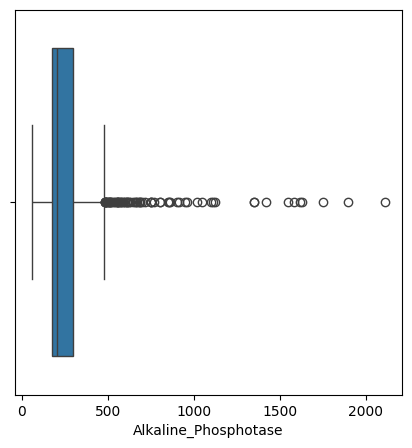

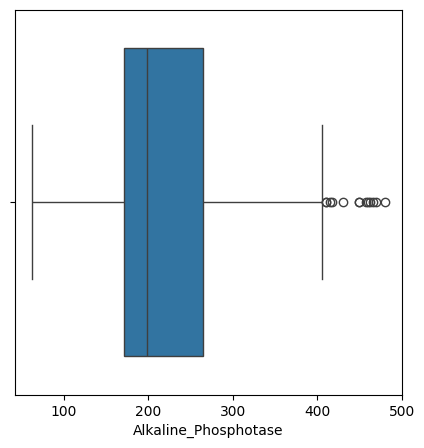

In [5]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=df['Alkaline_Phosphotase'],ax=ax)
q1=df['Alkaline_Phosphotase'].quantile(0.25)
q3=df['Alkaline_Phosphotase'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data1=df[(df['Alkaline_Phosphotase']>=lower_bound)&(df['Alkaline_Phosphotase']<=upper_bound)]
print(new_data1)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data1['Alkaline_Phosphotase'],ax=ax)

     Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0     65  Female              0.7               0.1                   187   
3     58    Male              1.0               0.4                   182   
4     72    Male              3.9               2.0                   195   
5     46    Male              1.8               0.7                   208   
6     26  Female              0.9               0.2                   154   
..   ...     ...              ...               ...                   ...   
577   32    Male             12.7               8.4                   190   
579   40    Male              0.6               0.1                    98   
580   52    Male              0.8               0.2                   245   
581   31    Male              1.3               0.5                   184   
582   38    Male              1.0               0.3                   216   

     Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  

<Axes: xlabel='Alamine_Aminotransferase'>

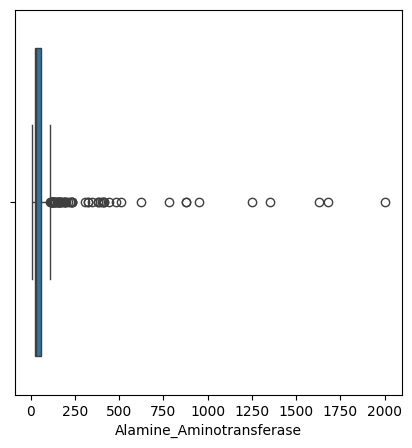

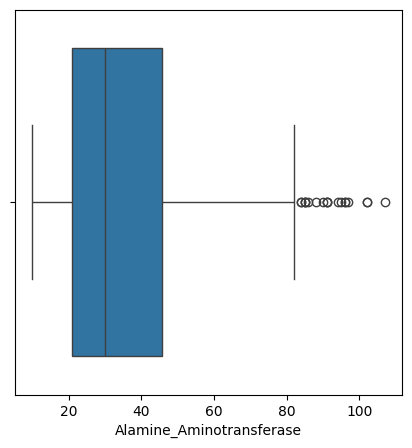

In [6]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data1['Alamine_Aminotransferase'],ax=ax)
q1=new_data1['Alamine_Aminotransferase'].quantile(0.25)
q3=new_data1['Alamine_Aminotransferase'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data2=new_data1[(new_data1['Alamine_Aminotransferase']>=lower_bound)&(new_data1['Alamine_Aminotransferase']<=upper_bound)]
print(new_data2)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data2['Alamine_Aminotransferase'],ax=ax)

     Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0     65  Female              0.7               0.1                   187   
3     58    Male              1.0               0.4                   182   
4     72    Male              3.9               2.0                   195   
5     46    Male              1.8               0.7                   208   
6     26  Female              0.9               0.2                   154   
..   ...     ...              ...               ...                   ...   
577   32    Male             12.7               8.4                   190   
579   40    Male              0.6               0.1                    98   
580   52    Male              0.8               0.2                   245   
581   31    Male              1.3               0.5                   184   
582   38    Male              1.0               0.3                   216   

     Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  

<Axes: xlabel='Aspartate_Aminotransferase'>

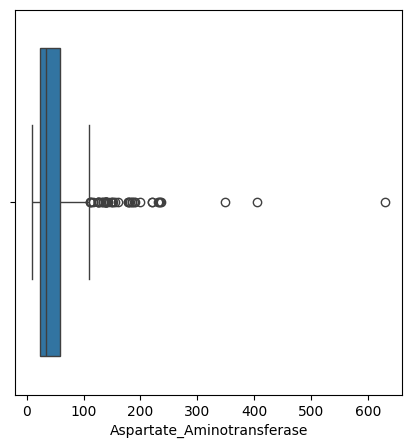

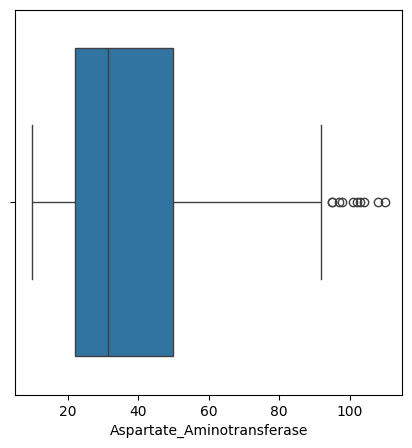

In [7]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data2['Aspartate_Aminotransferase'],ax=ax)
q1=new_data2['Aspartate_Aminotransferase'].quantile(0.25)
q3=new_data2['Aspartate_Aminotransferase'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data3=new_data2[(new_data2['Aspartate_Aminotransferase']>=lower_bound)&(new_data2['Aspartate_Aminotransferase']<=upper_bound)]
print(new_data3)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data3['Aspartate_Aminotransferase'],ax=ax)

<Axes: >

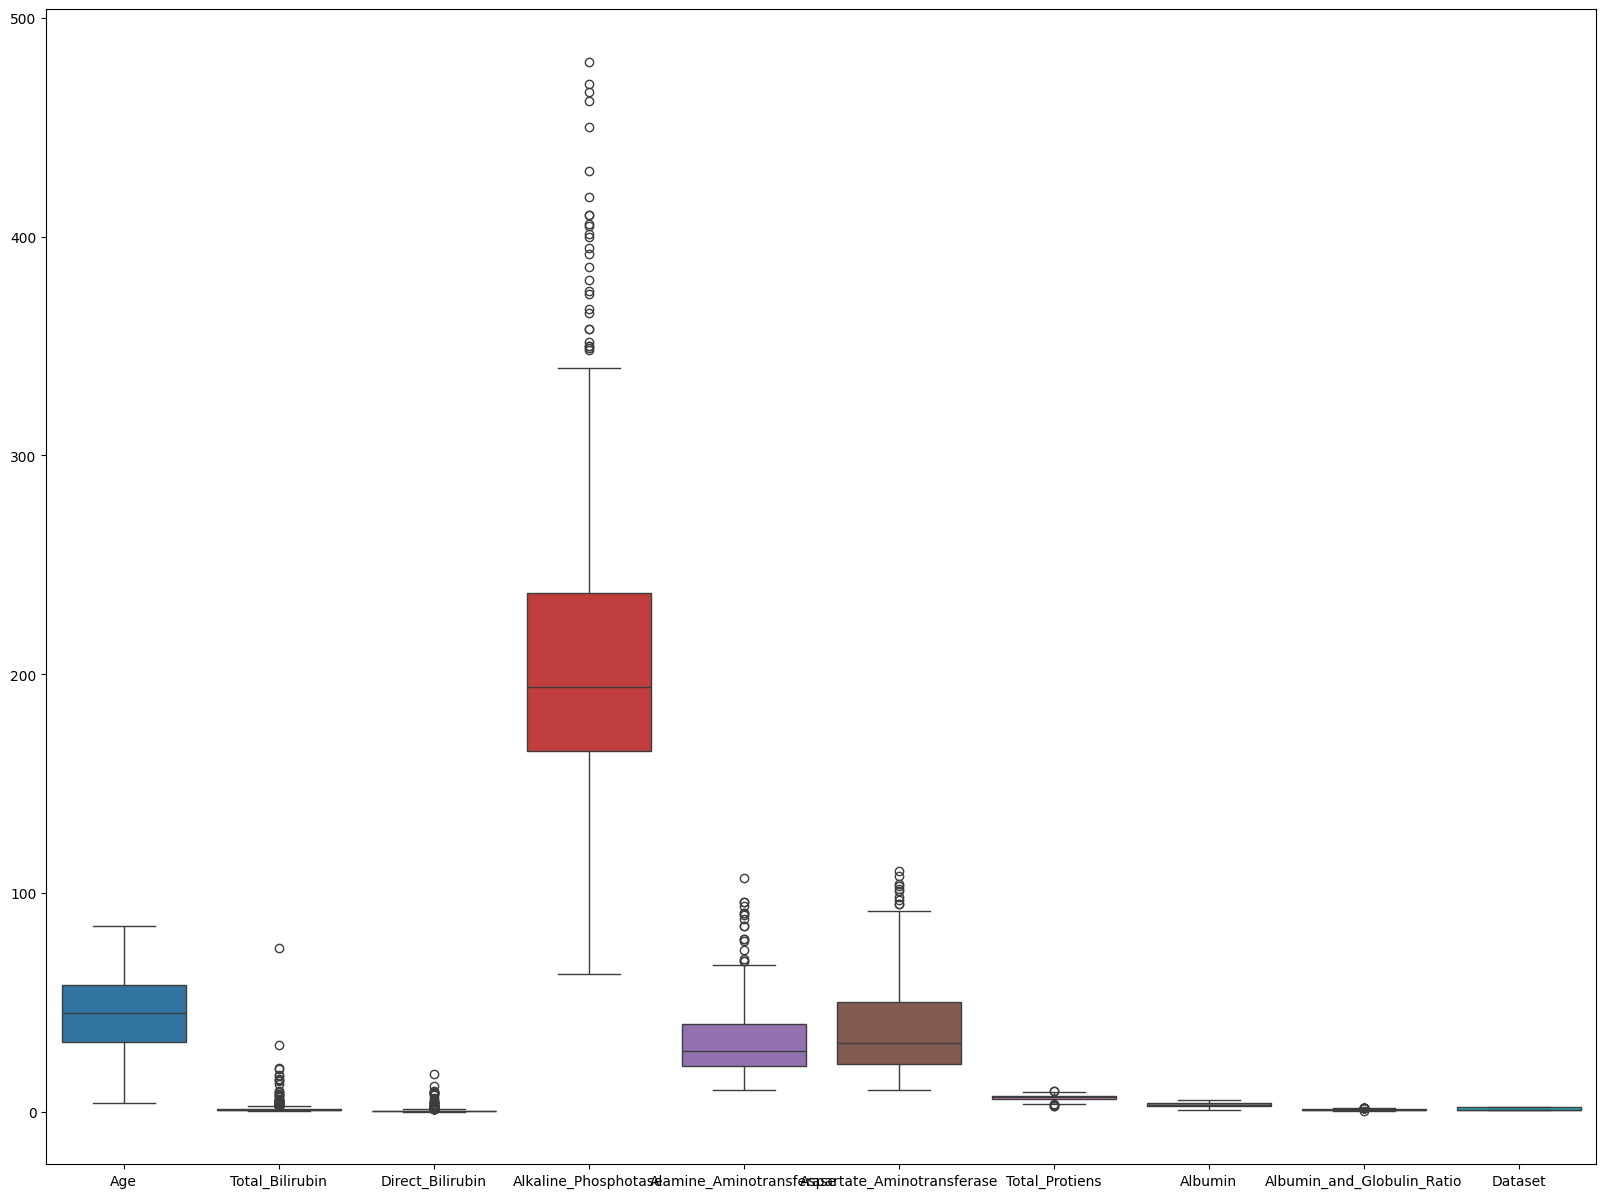

In [8]:
fig, ax = plt.subplots(figsize=(20,15))
sns.boxplot(data=new_data3,ax=ax)

In [9]:
new_data3_numeric = new_data3.copy()
new_data3_numeric['Gender'] = new_data3_numeric['Gender'].map({'Male': 0, 'Female': 1})
correlation = new_data3_numeric.corr()
correlation

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
Age,1.000000,-0.064220,0.027239,0.015493,0.005902,-0.029167,0.014187,-0.228497,-0.281707,-0.204143,-0.144281
Gender,-0.064220,1.000000,-0.076652,-0.094915,-0.050618,-0.161932,-0.159226,0.098114,0.078935,-0.002485,0.057643
Total_Bilirubin,0.027239,-0.076652,1.000000,0.659214,0.196284,0.156049,0.261177,-0.115907,-0.191430,-0.194027,-0.147391
Direct_Bilirubin,0.015493,-0.094915,0.659214,1.000000,0.213808,0.201769,0.349030,-0.164169,-0.251197,-0.239658,-0.198615
Alkaline_Phosphotase,0.005902,-0.050618,0.196284,0.213808,1.000000,0.233423,0.251730,0.030151,-0.088879,-0.223503,-0.167579
Alamine_Aminotransferase,-0.029167,-0.161932,0.156049,0.201769,0.233423,1.000000,0.555817,0.002208,0.027402,0.010802,-0.119787
Aspartate_Aminotransferase,0.014187,-0.159226,0.261177,0.349030,0.251730,0.555817,1.000000,-0.141564,-0.182408,-0.151520,-0.149232
Total_Protiens,-0.228497,0.098114,-0.115907,-0.164169,0.030151,0.002208,-0.141564,1.000000,0.848195,0.312554,0.041752
Albumin,-0.281707,0.078935,-0.191430,-0.251197,-0.088879,0.027402,-0.182408,0.848195,1.000000,0.736504,0.131472
Albumin_and_Globulin_Ratio,-0.204143,-0.002485,-0.194027,-0.239658,-0.223503,0.010802,-0.151520,0.312554,0.736504,1.000000,0.136174


<Axes: >

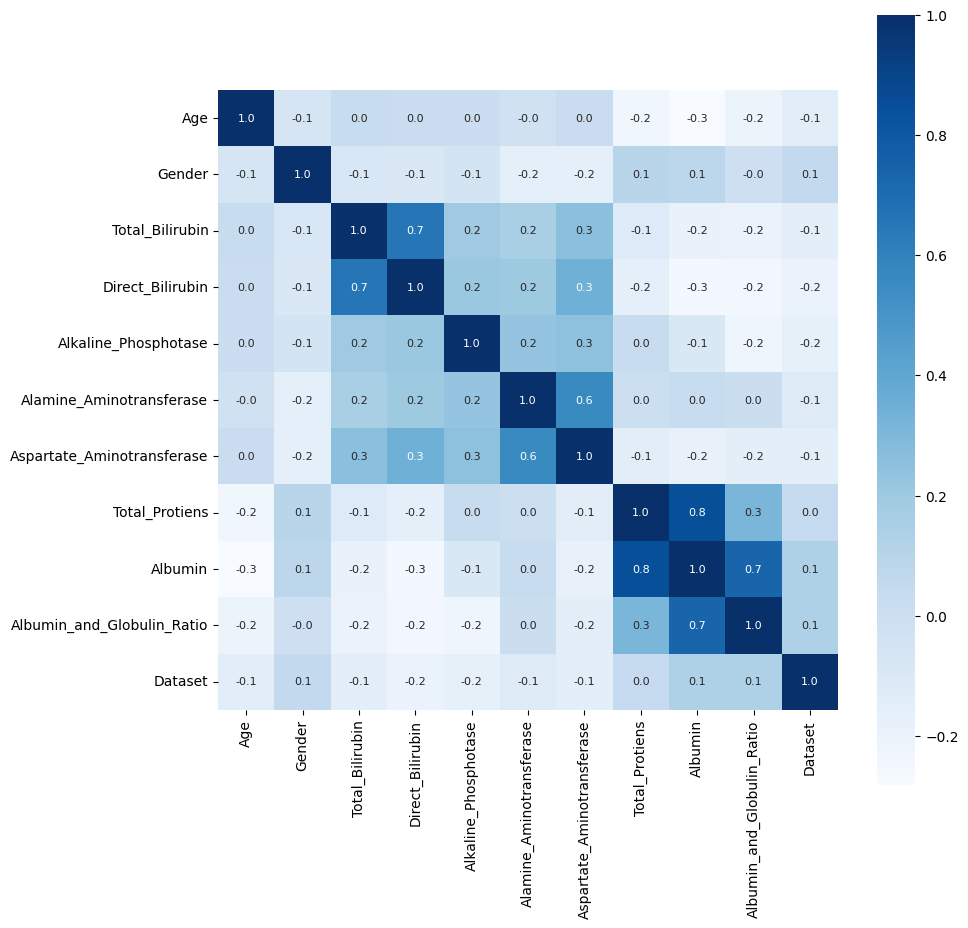

In [10]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [12]:
from imblearn.over_sampling import SMOTE

x = new_data3_numeric.drop('Dataset', axis=1)
y = new_data3_numeric['Dataset']

smote=SMOTE()
x_resampled,y_resampled=smote.fit_resample(x,y)
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.3,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape,y_resampled.shape,x_resampled.shape
model=RandomForestClassifier()
model.fit(x_train,y_train)


RandomForestClassifier()

In [13]:
training_data_prediction=model.predict(x_train)
training_data_accuracy=accuracy_score(training_data_prediction,y_train)
print(training_data_accuracy)
testing_data_prediction=model.predict(x_test)
testing_data_accuracy=accuracy_score(testing_data_prediction,y_test)
print(testing_data_accuracy)


1.0
0.7354838709677419


In [14]:
cm=confusion_matrix(y_test,testing_data_prediction)
print(cm)
print(classification_report(y_test, testing_data_prediction))

[[56 27]
 [14 58]]
              precision    recall  f1-score   support

           1       0.80      0.67      0.73        83
           2       0.68      0.81      0.74        72

    accuracy                           0.74       155
   macro avg       0.74      0.74      0.74       155
weighted avg       0.75      0.74      0.74       155



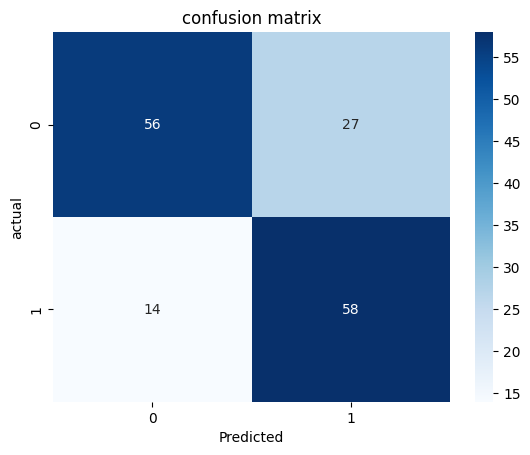

In [15]:
sns.heatmap(cm,annot=True,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

In [16]:
new_data=(45,1,4.2,1.5,210,41,23,4,2.9,0.3)
new_data_array=np.asarray(new_data)
new_data_reshaped=new_data_array.reshape(1,-1)
prediction=model.predict(new_data_reshaped)
if(prediction[0]==0):
  print('the person is not a patient')
else:
  print('the person is a patient')

the person is a patient


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
